## Build simple agents

LangChain provides create_agent() function to create production-ready agent implementation. It builds a graph-based agent runtime using LangGraph.

Using creat_agent function, one can provide following:

- Model
- Tools
- System Prompts
- Memory configurations
- Guardrails
- Middleware

In [30]:
from langchain.agents import create_agent
from langchain_ollama import OllamaLLM

### Create simple agent

In [31]:
llm = OllamaLLM(model="gemma3:1b", base_url="http://localhost:11434")
# Create a simple agent with a system prompt
agent = create_agent(    
   llm,
    system_prompt="You are a helpful assistant."
)

In [17]:
print(agent.get_graph().draw_ascii())

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
  +-------+    
  | model |    
  +-------+    
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


In [32]:
# Run the agent
result = agent.invoke(
    {"messages": [{"role": "user", "content": "what is LangGraph?"}]}
)

print(result["messages"][-1].content)

Okay, let's talk about LangGraph!

**LangGraph is a powerful, open-source tool for visualizing and analyzing graph data.** It’s designed to help you understand relationships, patterns, and trends within complex datasets that can be represented as graphs. 

Here’s a breakdown of what makes it special and why it’s useful:

**1. What is a Graph?**

First, let’s quickly recap what a graph is. It’s a way to represent data as a collection of *nodes* (things) and *edges* (connections) between those things. Think of it like a map of relationships – people connected by friendships, products connected by purchases, or data points linked by common interests.

**2. What does LangGraph do?**

LangGraph focuses on making graph data *accessible* and *interpretable*. It provides several key features:

* **Interactive Visualizations:** It lets you create stunning visualizations of your graph data. You can explore connections, size nodes, color data, and more, in a dynamic way.
* **Customizable Views:**

### Using tools

In [88]:
# import packages for tool
from langchain.tools import tool
# use ChatOllama for greeting tool. OllamaLLM dont have bind_tools method
from langchain_ollama import ChatOllama

In [89]:
# Use ChatOllama (NOT OllamaLLM)
chat_ollama_model = ChatOllama(model="llama3.2:1b", base_url="http://localhost:11434")

In [90]:
# Create a simple tool
@tool
def greet_user(name: str) -> str:
    """Greets the user with their name."""
    return f"Hello brother, {name}! How are are you doing today? Welcome!"

# Add the tool to the agent
greeting_agent = create_agent(    
   chat_ollama_model,
   tools=[greet_user],
   system_prompt="You are a helpful assistant. Use the greet_user tool for greeting users by their name in dramatic way."
)

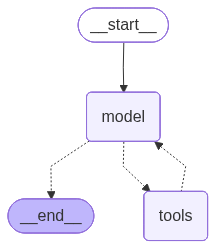

In [91]:
# Display the graph
#print(greeting_agent.get_graph().draw_ascii())
greeting_agent

In [92]:
# The agent will use the greeting tool
greet_result = greeting_agent.invoke(    
    {"messages": [{"role": "user", "content": "My name is Vaibhav. How would you greet me?"}]}
)

#print(greet_result)
print(greet_result["messages"][-2].content)

Hello brother, Vaibhav! How are are you doing today? Welcome!
